In [11]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay, classification_report
from typing import Tuple
import matplotlib.pyplot as plt

In [27]:
X, y = make_classification(
    n_samples = 2000,
    n_features = 2,
    n_informative = 2,
    n_redundant = 0,
    n_classes = 2,
    random_state = 10
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 10)

# Train the model
model = LogisticRegression().fit(X_train, y_train)


Now we evaluate the model using different metrics.

- Accuracy Score
$$
Accuracy = \frac{TP + TN}{N}
$$

- Receiver Operating Characteristic Curve (ROC): pairs of TPR (True Positive Rate) and FPR (False Positive Rate)
$$
TPR = \frac{TP}{TP + FN}
$$
$$
FPR = \frac{FP}{FP + TN}
$$

- Area Under the ROC curve (AUC)
$$
AUC = \int_{0}^{1} TPR(FPR)d(FPR)
$$

- Confusion Matrix
$$
\begin{bmatrix}
TN & FP\\
FN & TP
\end{bmatrix}
$$

- Classification Report
    - Precision
    $$
    \frac{TP}{TP + FP}
    $$
    - Recall(TPR)
    $$
    \frac{TP}{TP + FN}
    $$
    - F1-Score
    $$
    2\cdot \frac{Precision\cdot Recall}{Precision + Recall}
    $$

In [28]:
def Model_evaluation(model: LogisticRegression, x: np.ndarray, y: np.ndarray) -> Tuple:
    """
    Evaluating the input logistic regression model.

    Args:
        model (LogisticRegression): The trained model.
        x (np.ndarray): Input features.
        y (np.ndarray): True labels.

    Returns:
        Tuple (accuracy_score, FPR, TPR, AUC of roc, Confusion Matrix, classification_report)
    """
    predictions = model.predict(x)
    acc_score = accuracy_score(y_true = y, y_pred = predictions)
    fpr, tpr, _ = roc_curve(y_true = y, y_score = model.predict_proba(x)[:, 1])
    area_roc = auc(fpr, tpr)
    cm = confusion_matrix(y_true = y, y_pred = predictions)
    class_report = classification_report(y_true = y, y_pred = predictions)

    return acc_score, fpr, tpr, area_roc, cm, class_report

In [29]:
acc_score, fpr, tpr, area_roc, cm, class_report = Model_evaluation(model, X_test, y_test)
print(f"Accuracy Score = {acc_score}\n\n Classification Report:\n {class_report}")

Accuracy Score = 0.824

 Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.87      0.84       261
           1       0.84      0.78      0.81       239

    accuracy                           0.82       500
   macro avg       0.83      0.82      0.82       500
weighted avg       0.83      0.82      0.82       500



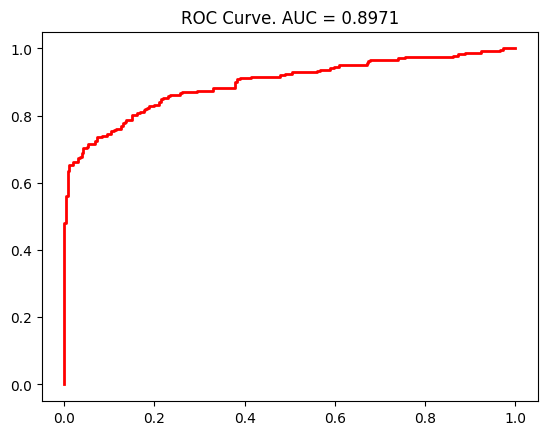

In [35]:
# Plot ROC Curve
plt.plot(fpr, tpr, color = "red", linewidth = 2)
plt.title(f"ROC Curve. AUC = {area_roc:.4f}")
plt.show()


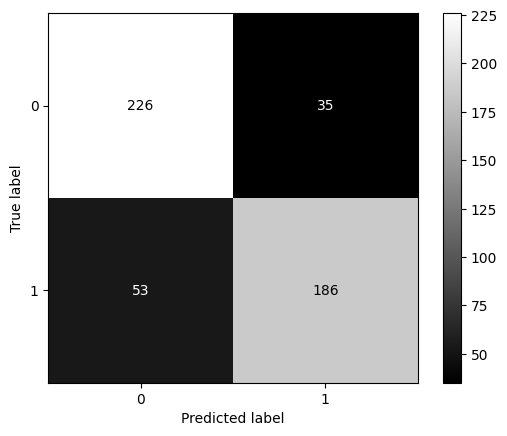

In [47]:
cm_plot = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [0, 1])

cm_plot.plot(cmap = plt.cm.gray)